<a href="https://colab.research.google.com/github/Badar-Islam/delivery-time-prediction-NN/blob/main/Porter_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> # <b>Porter - Neural Networks Regression:</b>

> ## **Problem Statement:**

Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers.

Porter works with a wide range of restaurants for delivering their items directly to the people.
Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

This dataset has the required data to train a regression model that will do the delivery time estimation, based on all those features


In [ ]:
!gdown 14plC46-V5y92IZo_K4No6Ex7RdkP8FI-

Downloading...
From: https://drive.google.com/uc?id=14plC46-V5y92IZo_K4No6Ex7RdkP8FI-
To: /content/dataset.csv
100% 23.8M/23.8M [00:00<00:00, 104MB/s]


> ## **Data Dictionary:**
1.	**market_id** : integer id for the market where the restaurant lies
2.	**created_at** : the timestamp at which the order was placed
3.	**actual_delivery_time** : the timestamp when the order was delivered
4.	**store_primary_category** : category for the restaurant
5.	**order_protocol** : integer code value for order protocol (how the order was placed ie: through porter, call to restaurant, pre booked, third part etc)
6.	**total_items subtotal** : A combined feature detailing the total number of items in
the order and the final price of the order before taxes and fees
7.	**num_distinct_items** : the number of distinct items in the order
8.	**min_item_price** : price of the cheapest item in the order
9.	**max_item_price** : price of the costliest item in order
10.	**total_onshift_partners** : number of delivery partners on duty at the time order was placed
11.	**total_busy_partners** : number of delivery partners attending to other tasks
12.	**total_outstanding_orders** : total number of orders to be fulfilled at the moment


In [ ]:
# importing library to perform EDA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('dataset.csv')
data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [ ]:
df = data.copy()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

> ### **Insights**:
- `Store id` seems to be meaningless feature to perform EDA, we can simply drop it from the dataset.
- `actual_delivery_time` and `created_at` are dates, so assigning them the correct datatype.
- To perform EDA, converting `market_id` to object type.

In [ ]:
data.drop(columns=['store_id'], inplace=True)
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])
data['created_at'] = pd.to_datetime(data['created_at'])
data['market_id'] = data['market_id'].astype('object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 196441 non-null  object        
 1   created_at                197428 non-null  datetime64[ns]
 2   actual_delivery_time      197421 non-null  datetime64[ns]
 3   store_primary_category    192668 non-null  object        
 4   order_protocol            196433 non-null  float64       
 5   total_items               197428 non-null  int64         
 6   subtotal                  197428 non-null  int64         
 7   num_distinct_items        197428 non-null  int64         
 8   min_item_price            197428 non-null  int64         
 9   max_item_price            197428 non-null  int64         
 10  total_onshift_partners    181166 non-null  float64       
 11  total_busy_partners       181166 non-null  float64       
 12  to

In [ ]:
round((data.isnull().sum()/data.shape[0])*100, 2)

,0
market_id,0.50
created_at,0.00
actual_delivery_time,0.00
store_primary_category,2.41
order_protocol,0.50
total_items,0.00
subtotal,0.00
num_distinct_items,0.00
min_item_price,0.00
max_item_price,0.00


> ### **Insights**:
- dataset contains null values under multiple columns, we will be dealing with them later on.

In [ ]:
data.created_at.max() - data.created_at.min()

Timedelta('122 days 00:36:29')

> #### Feature Engineering:
In order to solve the given problem `calculating the delivery time`, we will be needing various features which can be extracted from available features.... just doing the same.

In [ ]:
data['delivary_time_in_mins'] = (data.actual_delivery_time - data.created_at)/pd.Timedelta(minutes=1)
data['hour_of_day'] = data.created_at.dt.hour
data['day_of_week'] = data.created_at.dt.weekday
data['month_of_year'] = data.created_at.dt.month
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333,22,4,2
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667,21,1,2
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333,20,3,1
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51.250000,21,1,2
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333,2,6,2


In [ ]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
created_at,197428,2015-02-04 22:00:09.537962752,2014-10-19 05:24:15,2015-01-29 02:32:42,2015-02-05 03:29:09.500000,2015-02-12 01:39:18.500000,2015-02-18 06:00:44,NaN
actual_delivery_time,197421,2015-02-04 22:48:23.348914432,2015-01-21 15:58:11,2015-01-29 03:22:29,2015-02-05 04:40:41,2015-02-12 02:25:26,2015-02-19 22:45:31,NaN
order_protocol,196433.0,2.882352,1.0,1.0,3.0,4.0,7.0,1.503771
total_items,197428.0,3.196391,1.0,2.0,3.0,4.0,411.0,2.666546
subtotal,197428.0,2682.331402,0.0,1400.0,2200.0,3395.0,27100.0,1823.093688
num_distinct_items,197428.0,2.670791,1.0,1.0,2.0,3.0,20.0,1.630255
min_item_price,197428.0,686.21847,-86.0,299.0,595.0,949.0,14700.0,522.038648
max_item_price,197428.0,1159.58863,0.0,800.0,1095.0,1395.0,14700.0,558.411377
total_onshift_partners,181166.0,44.808093,-4.0,17.0,37.0,65.0,171.0,34.526783
total_busy_partners,181166.0,41.739747,-5.0,15.0,34.0,62.0,154.0,32.145733


> ### **Insights**:
- there seems to be quite a outlier, an very obvious seems to be the max delivery time which shows 141947 mins taken to deliver something compare to an overall average of just 48 mins in the dataset.
- we will be dealing with outliers later.
- To perform EDA, creating a new feature `day_hour` for better understanding the trafic hours.

In [ ]:
def day_hours(x):
  if 0<=x<=5:
    return 'Night'
  elif 6<=x<=11:
    return 'Morning'
  elif 12<=x<=17:
    return 'Afternoon'
  else:
    return 'Evening'
data['day_times'] = data.hour_of_day.apply(day_hours)

In [ ]:
data.describe(include='object').T

,count,unique,top,freq
market_id,196441.0,6.0,2.0,55058.0
store_primary_category,192668,74,american,19399
day_times,197428,4,Night,127249


In [ ]:
data[data['total_outstanding_orders']<0]

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year,day_times
4989,1.0,2015-02-18 00:36:21,2015-02-18 01:12:28,smoothie,2.0,2,1940,1,840,856,11.0,14.0,-2.0,36.116667,0,2,2,Night
19438,3.0,2015-02-03 03:04:22,2015-02-03 04:21:43,fast,4.0,3,1778,2,158,869,7.0,10.0,-2.0,77.350000,3,1,2,Night
20454,1.0,2015-01-25 21:15:30,2015-01-25 21:51:23,asian,1.0,3,2039,3,393,798,9.0,7.0,-1.0,35.883333,21,6,1,Evening
23029,1.0,2015-02-08 19:49:17,2015-02-08 21:10:48,korean,1.0,2,1641,2,754,1217,5.0,2.0,-1.0,81.516667,19,6,2,Evening
36317,1.0,2015-01-31 17:32:31,2015-01-31 18:04:30,fast,4.0,3,617,2,258,365,6.0,6.0,-6.0,31.983333,17,5,1,Afternoon
44415,1.0,2015-01-27 01:50:34,2015-01-27 02:23:54,other,1.0,3,2258,2,126,837,24.0,8.0,-2.0,33.333333,1,1,1,Night
46884,1.0,2015-02-17 02:55:02,2015-02-17 04:41:16,american,4.0,1,1317,1,1058,1042,6.0,7.0,-3.0,106.233333,2,1,2,Night
50842,1.0,2015-01-21 18:46:51,2015-01-21 19:25:30,american,1.0,1,4314,1,4147,4077,9.0,-2.0,-5.0,38.650000,18,2,1,Evening
56554,3.0,2015-01-23 00:25:58,2015-01-23 01:13:54,pizza,1.0,3,1963,2,562,855,2.0,5.0,-6.0,47.933333,0,4,1,Night
68176,1.0,2015-02-18 01:50:48,2015-02-18 02:46:53,chinese,5.0,4,3146,4,468,945,2.0,5.0,-3.0,56.083333,1,2,2,Night


In [ ]:
data[data['total_busy_partners']<0]

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year,day_times
7997,1.0,2015-02-08 15:41:45,2015-02-08 16:35:01,sandwich,3.0,1,1514,1,1116,1063,1.0,-1.0,3.0,53.266667,15,6,2,Afternoon
22673,1.0,2015-02-10 19:35:28,2015-02-10 20:28:51,japanese,1.0,2,1578,2,441,803,0.0,-1.0,9.0,53.383333,19,1,2,Evening
24662,1.0,2015-01-29 05:09:24,2015-01-29 05:41:44,catering,3.0,1,1237,1,984,978,5.0,-1.0,7.0,32.333333,5,3,1,Night
26627,1.0,2015-02-13 03:18:12,2015-02-13 04:23:16,burger,1.0,6,5773,6,554,1926,10.0,-1.0,6.0,65.066667,3,4,2,Night
33276,1.0,2015-02-12 00:38:22,2015-02-12 01:04:33,steak,1.0,2,6083,2,2907,3199,9.0,-1.0,5.0,26.183333,0,3,2,Night
47959,3.0,2015-02-07 05:44:49,2015-02-07 06:23:57,indian,3.0,2,1859,2,295,1240,6.0,-1.0,8.0,39.133333,5,5,2,Night
50842,1.0,2015-01-21 18:46:51,2015-01-21 19:25:30,american,1.0,1,4314,1,4147,4077,9.0,-2.0,-5.0,38.650000,18,2,1,Evening
57384,3.0,2015-02-13 23:26:37,2015-02-14 00:06:14,mexican,1.0,2,1540,2,424,1236,6.0,-1.0,3.0,39.616667,23,4,2,Evening
59370,1.0,2015-01-30 19:55:28,2015-01-30 21:14:21,sushi,5.0,5,1900,5,331,305,5.0,-3.0,3.0,78.883333,19,4,1,Evening
59764,1.0,2015-02-17 01:04:53,2015-02-17 01:53:41,sandwich,1.0,1,1661,1,1136,1211,2.0,-4.0,12.0,48.800000,1,1,2,Night


In [ ]:
data[data['total_onshift_partners']<0]

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year,day_times
6034,3.0,2015-02-14 01:48:58,2015-02-14 03:00:13,american,1.0,2,3538,2,1238,1606,-2.0,2.0,10.0,71.250000,1,5,2,Night
12888,3.0,2015-01-21 21:02:32,2015-01-21 21:41:03,catering,2.0,1,986,1,892,827,-2.0,5.0,1.0,38.516667,21,2,1,Evening
26395,3.0,2015-02-08 18:28:15,2015-02-08 19:17:31,fast,3.0,2,1327,1,680,615,-1.0,6.0,6.0,49.266667,18,6,2,Evening
30897,3.0,2015-02-07 19:55:46,2015-02-07 20:46:27,hawaiian,1.0,1,1202,1,987,1092,-1.0,9.0,5.0,50.683333,19,5,2,Evening
33154,1.0,2015-02-02 22:27:36,2015-02-03 00:08:43,american,1.0,2,2831,2,681,635,-1.0,13.0,16.0,101.116667,22,0,2,Evening
53702,1.0,2015-01-25 02:55:01,2015-01-25 03:41:37,chinese,1.0,2,1803,2,818,1061,-1.0,4.0,7.0,46.600000,2,6,1,Night
60282,1.0,2015-01-29 02:07:49,2015-01-29 02:48:26,salad,5.0,2,1117,2,339,956,-3.0,0.0,16.0,40.616667,2,3,1,Night
61131,1.0,2015-02-01 03:42:22,2015-02-01 04:34:18,sushi,5.0,7,2666,7,379,437,-2.0,8.0,5.0,51.933333,3,6,2,Night
118311,1.0,2015-02-09 03:35:22,2015-02-09 04:36:05,japanese,3.0,2,1862,2,488,1162,-2.0,3.0,3.0,60.716667,3,0,2,Night
119242,3.0,2015-02-14 04:21:45,2015-02-14 05:40:08,seafood,4.0,4,1874,3,110,1378,-2.0,-1.0,11.0,78.383333,4,5,2,Night


> ### **Insights**:
- Somehow there seems to be values in the dataset which doesn't make much sense like `total_outstanding_order`, `total_busy_partners` and `total_onshift_partners` holding the values less than 0.
- Need more understanding over this, in order to take a call of keeping or removing them.

> ## **Univariate Analysis:**

In [ ]:
date_cols = data.select_dtypes(include='datetime').columns
num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(include='object').columns

In [ ]:
data.groupby(data['created_at'].dt.date)['delivary_time_in_mins'].agg(['mean', 'median'])

,mean,median
created_at,,
2014-10-19,141947.650000,141947.650000
2015-01-21,42.718351,39.683333
2015-01-22,44.202916,41.633333
2015-01-23,44.486253,42.316667
2015-01-24,49.823275,47.066667
2015-01-25,47.528008,44.600000
2015-01-26,42.202595,39.241667
2015-01-27,43.414060,40.733333
2015-01-28,45.311219,41.366667


> ### **Insights**:
- First Entry seems to be outlier, as it seems it took around 3 months for this delivery and only for this delivery we have such a huge timespan.

In [ ]:
data = data[data['created_at']!=data['created_at'].min()]
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year,day_times
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333,22,4,2,Evening
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667,21,1,2,Evening
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333,20,3,1,Evening
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51.250000,21,1,2,Evening
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333,2,6,2,Night


In [ ]:
data.groupby(data['created_at'])['delivary_time_in_mins'].agg(['mean', 'median'])

,mean,median
created_at,,
2015-01-21 15:22:03,55.666667,55.666667
2015-01-21 15:31:51,44.716667,44.716667
2015-01-21 15:39:16,18.916667,18.916667
2015-01-21 15:40:42,41.916667,41.916667
2015-01-21 15:41:33,53.683333,53.683333
...,...,...
2015-02-18 05:57:51,40.783333,40.783333
2015-02-18 05:58:07,17.933333,17.933333
2015-02-18 05:59:01,34.866667,34.866667


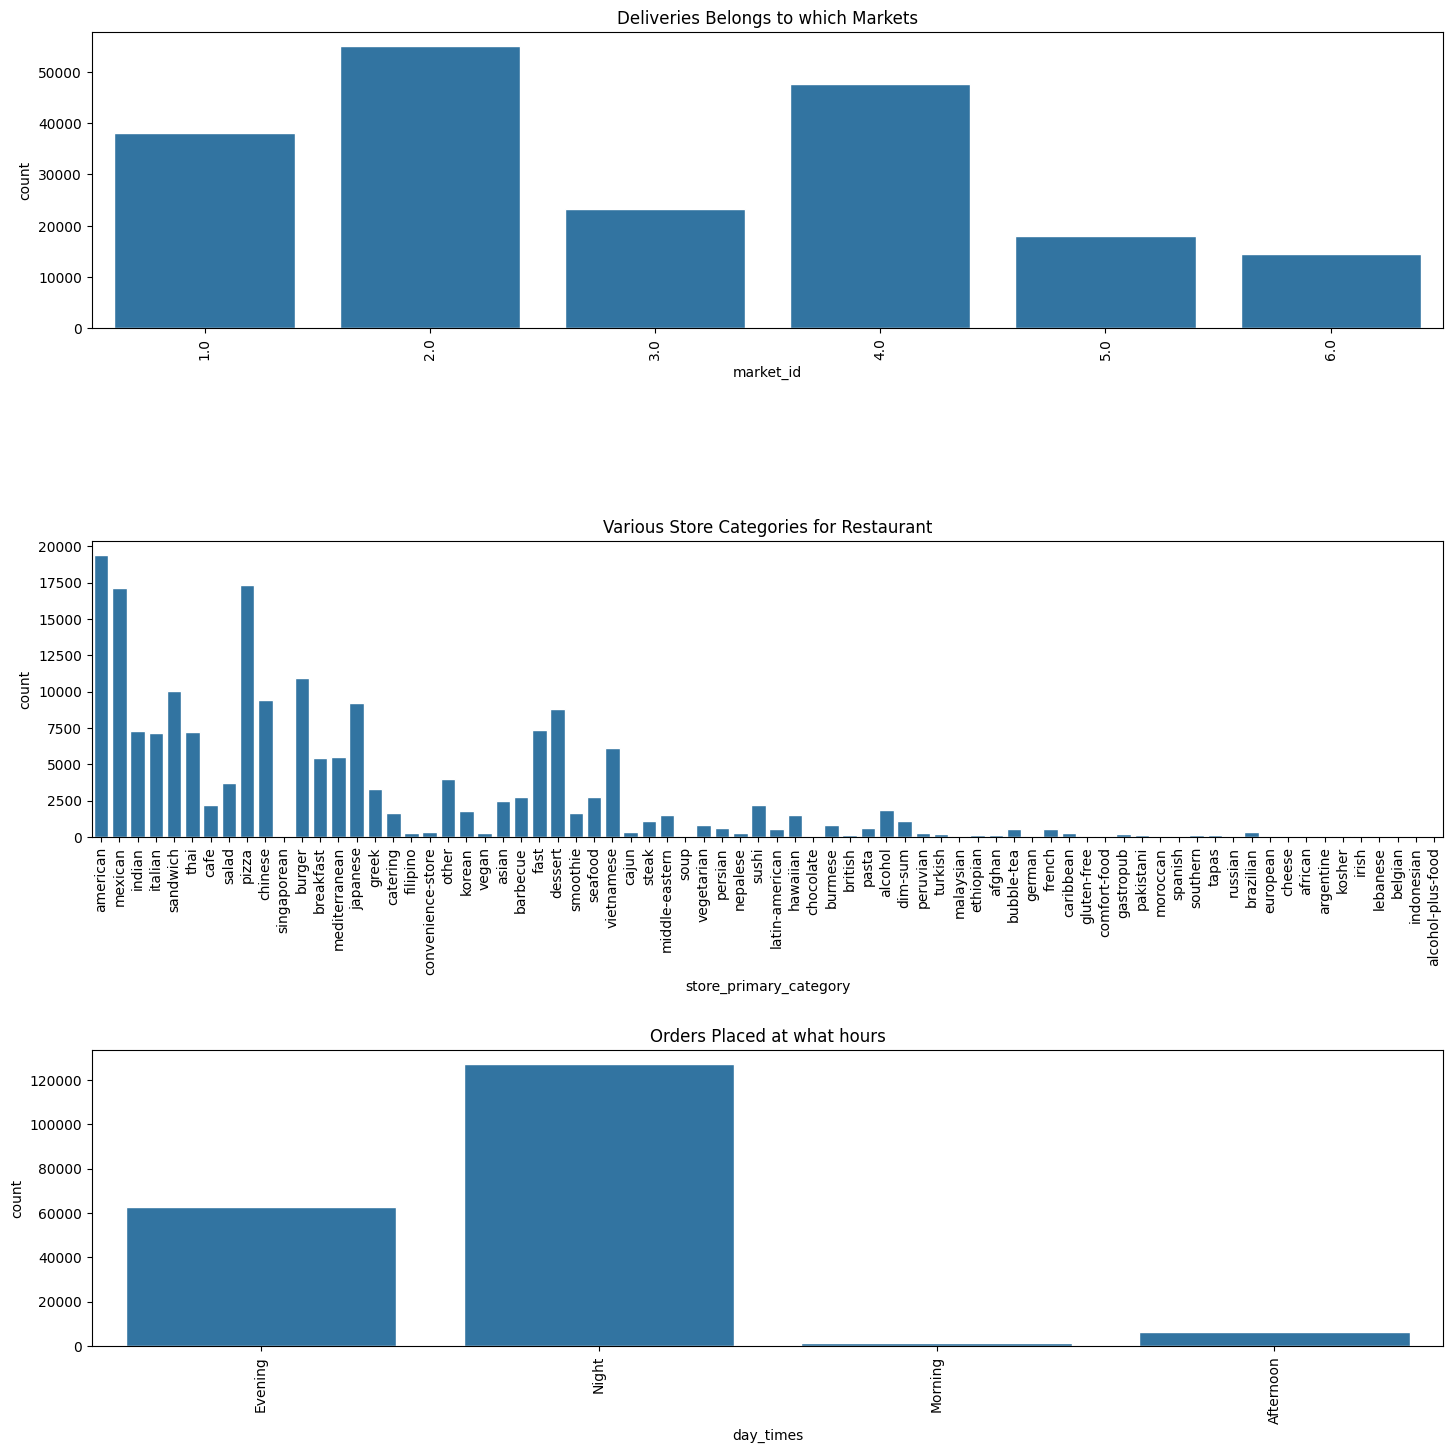

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(15,15))
ax = ax.flatten()
titles = ['Deliveries Belongs to which Markets', 'Various Store Categories for Restaurant', 'Orders Placed at what hours']

for i, col in enumerate(cat_cols):
  sns.set(style='dark')
  sns.countplot(data=data, x=col, ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(titles[i])
plt.tight_layout(pad=2)
plt.show()

> ### **Insights**:
- Most deliveries are from Market 2, followed by market 4.
- Most popular foods are American, Pizza and Mexican.
- Peak Hours for placing orders is in night whereas Morning is the least busy for placing orders.

In [ ]:
titles = []
for col in num_cols:
  array = np.array(col.split('_')).astype(str)
  array = ' '.join(array)
  titles.append(array.title())

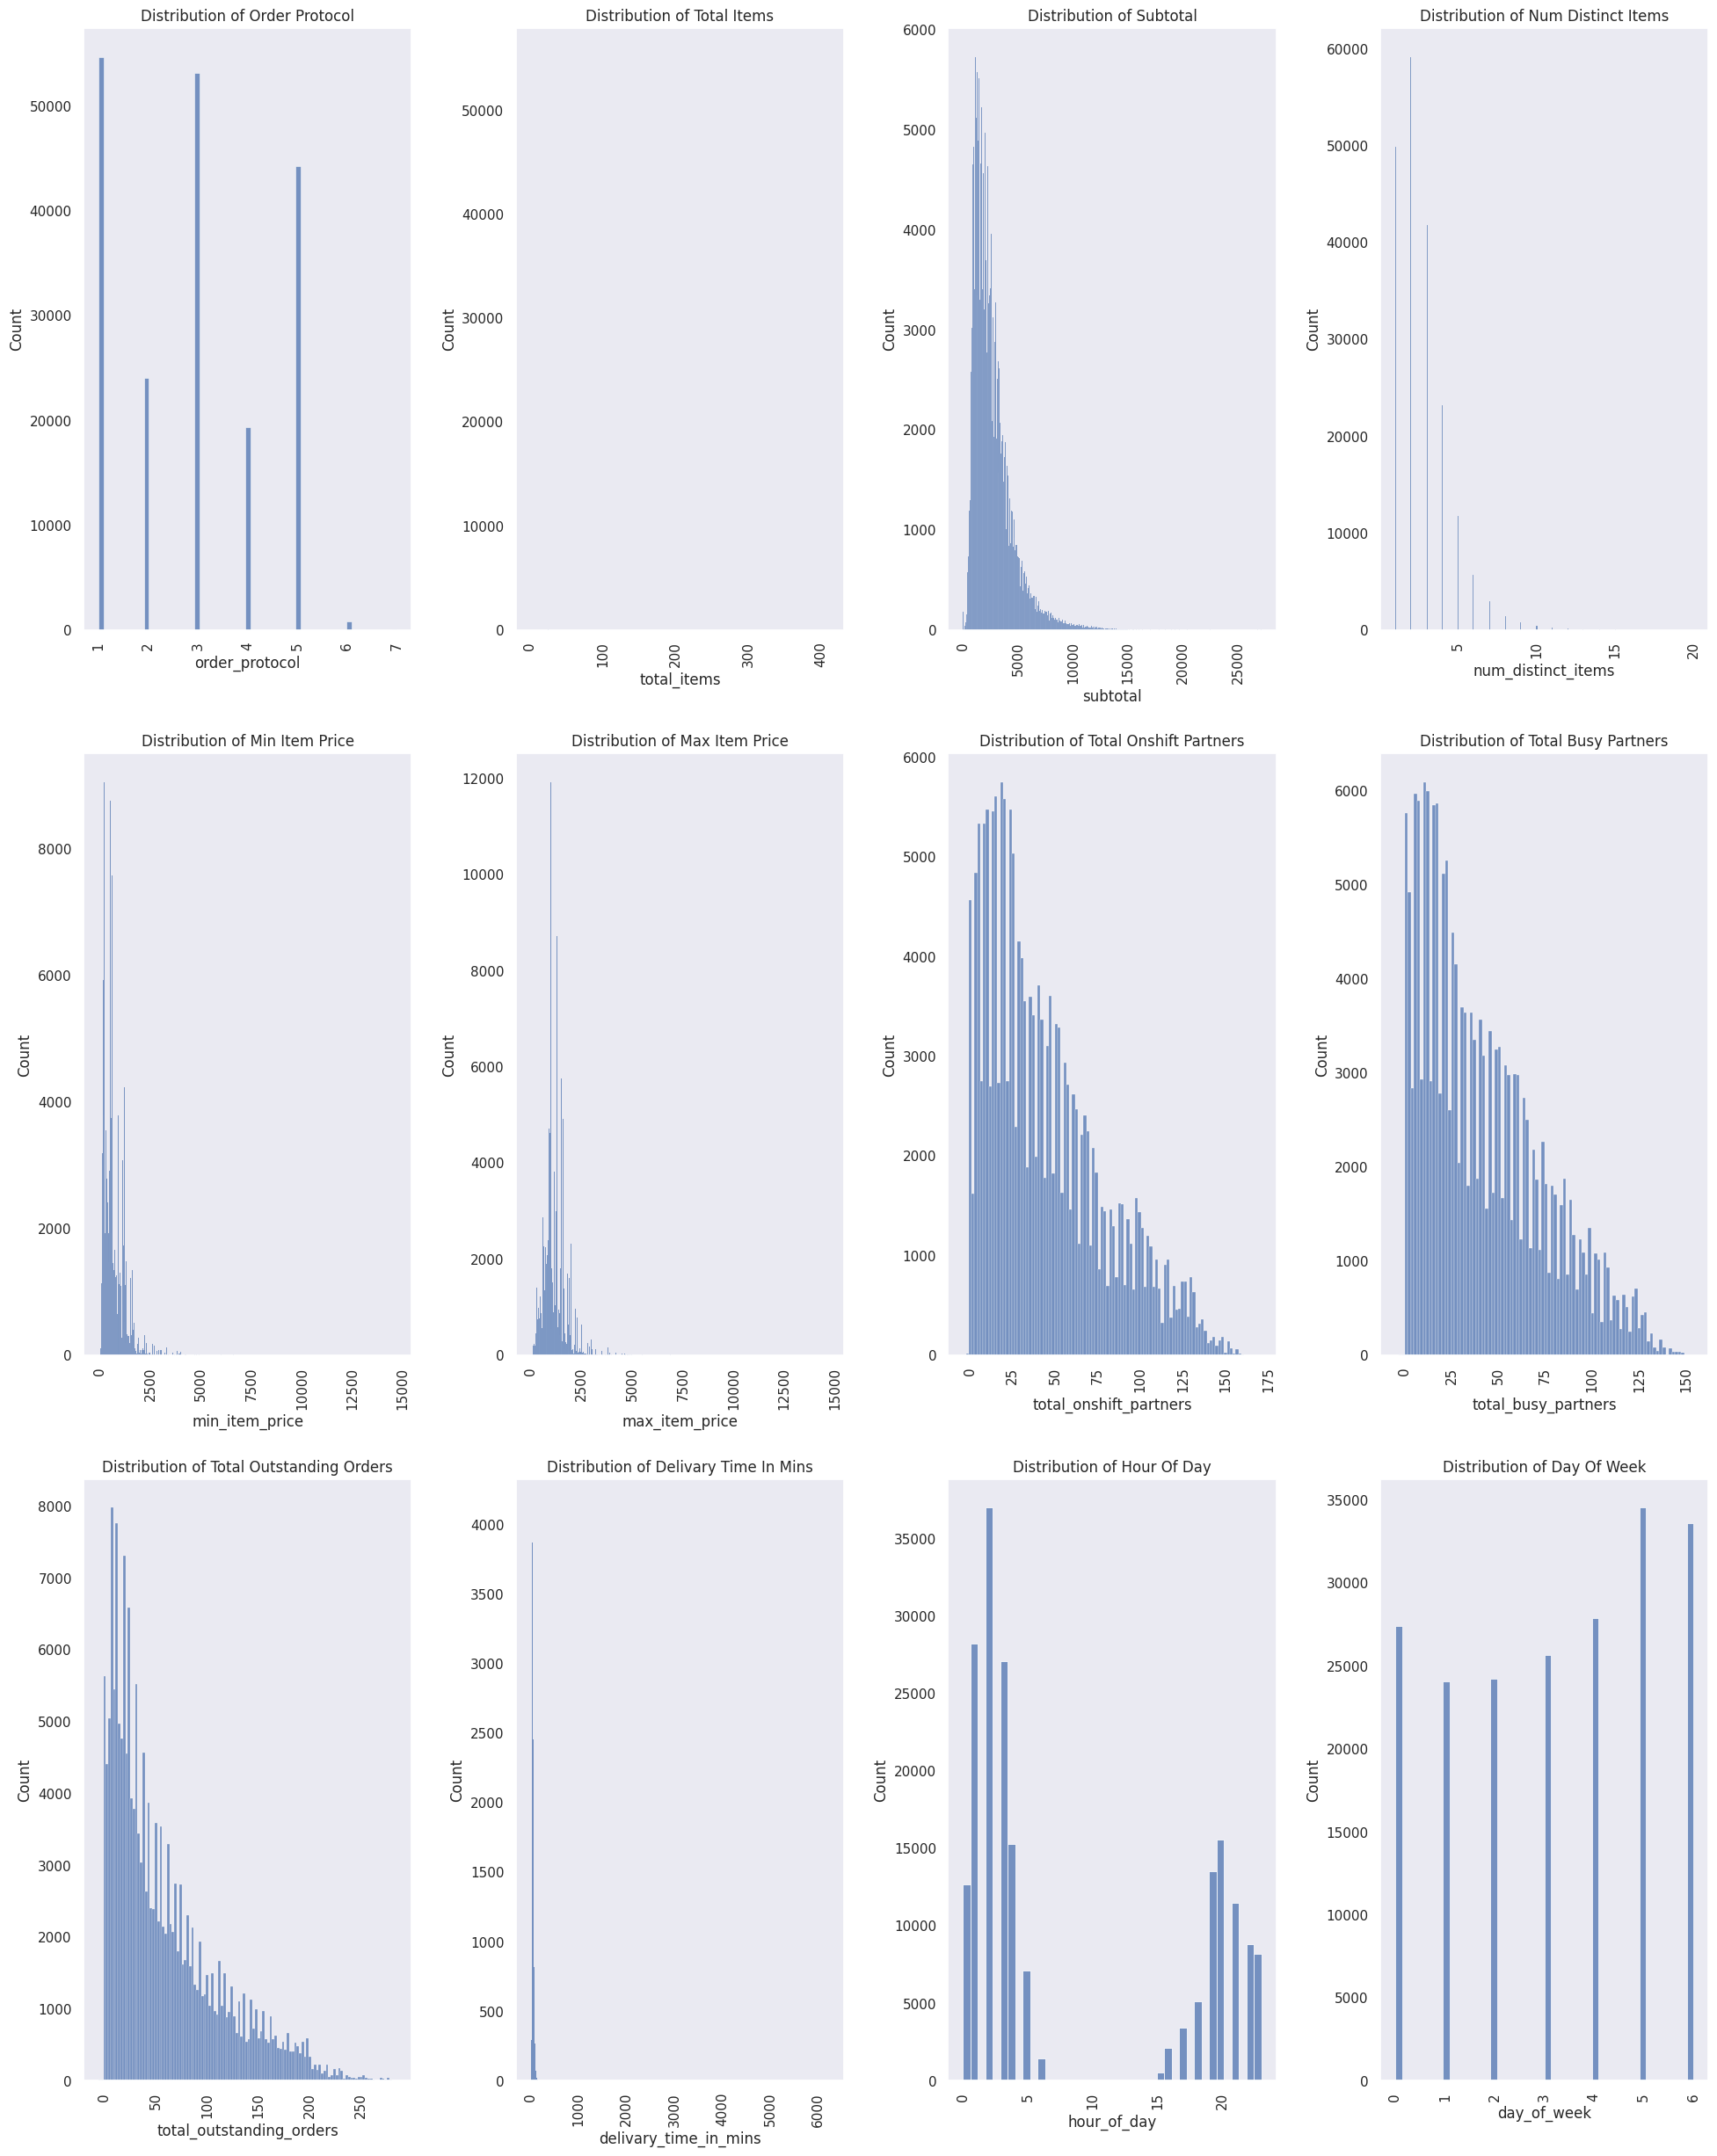

In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(20,25))
ax = ax.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.set(style='dark')
  sns.histplot(data=data, x=col, ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(f"Distribution of {titles[i]}")
plt.tight_layout(pad=2)
plt.show()

> ### **Insights**:
- Highest number of orders are placed on saturday and sunday.
- Peak hours to place order is between 1AM to 3AM (night time).
- ` total_outstanding_order`, `total_busy_partners` and `total_onshift_partners` seems to be correlated based on pattern shown above.

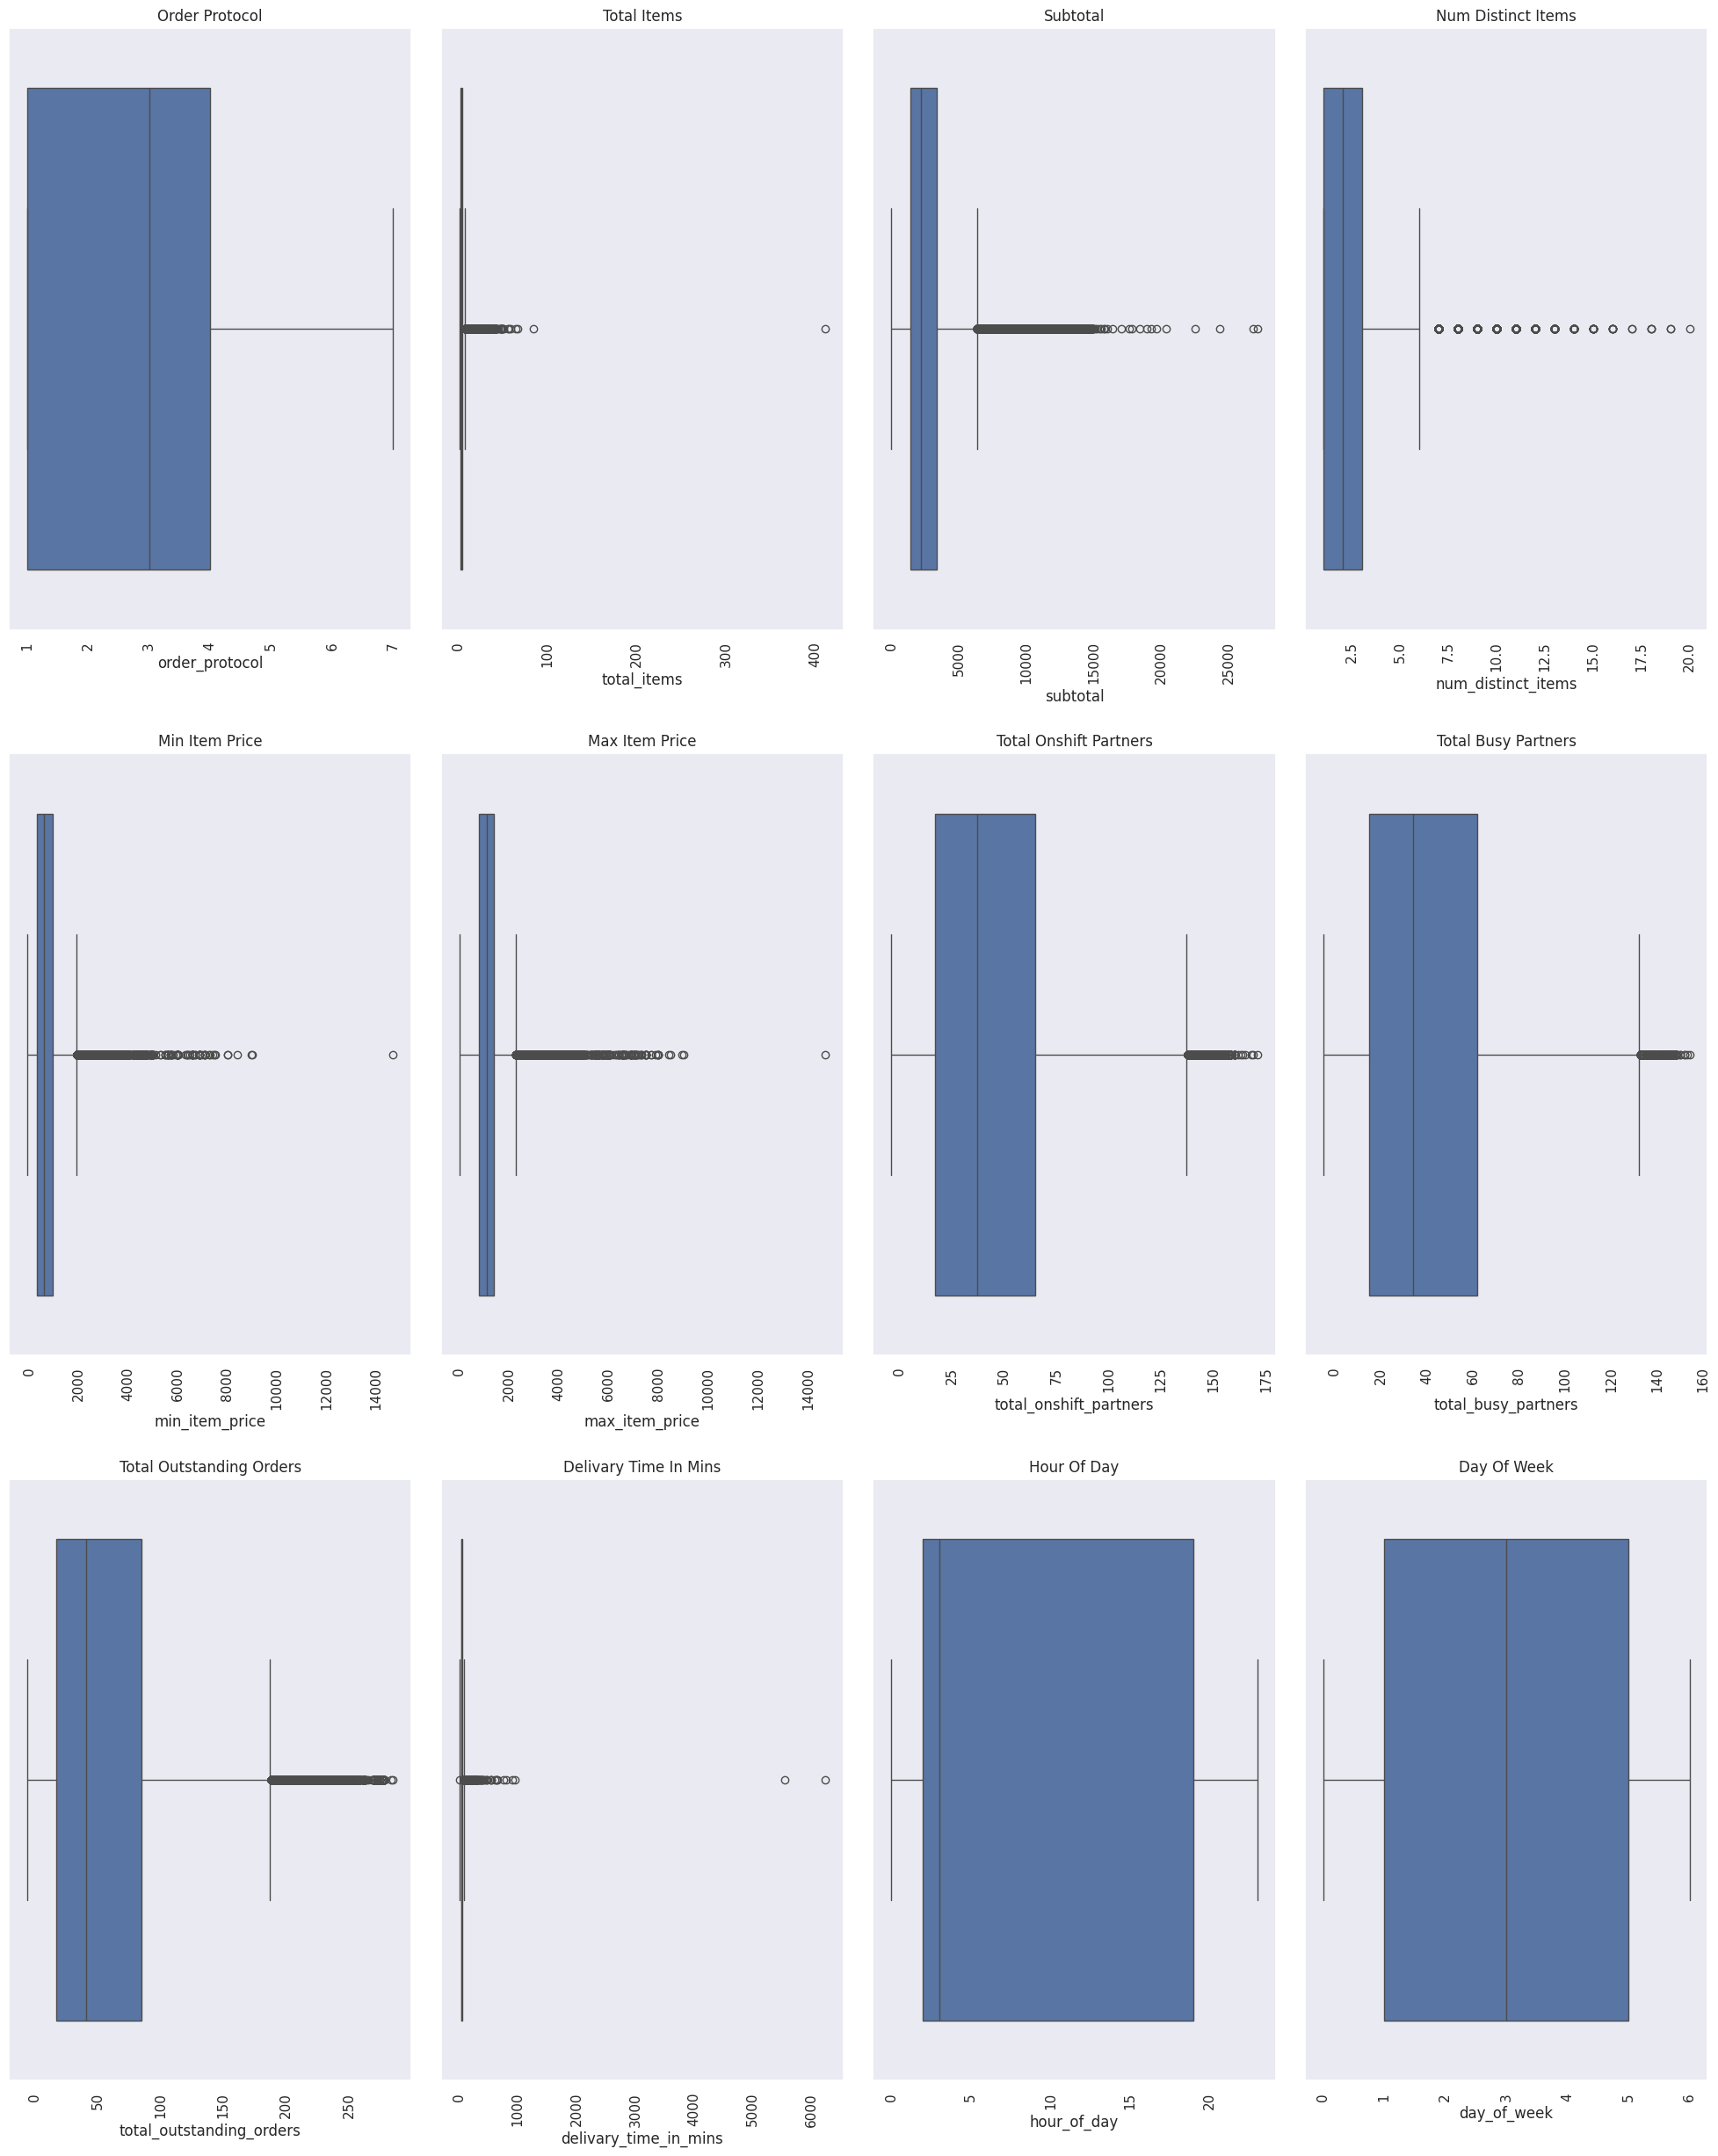

In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(20,25))
ax = ax.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.set(style='dark')
  sns.boxplot(data=data, x=col, ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(titles[i])
plt.tight_layout(pad=2)
plt.show()

In [ ]:
# creating some more feature to understand dataset better
data['created_at'] = data['created_at'].dt.date
data['actual_delivery_time'] = data['actual_delivery_time'].dt.date
data['average_delivery_time'] = data.groupby('created_at')['delivary_time_in_mins'].transform('mean')

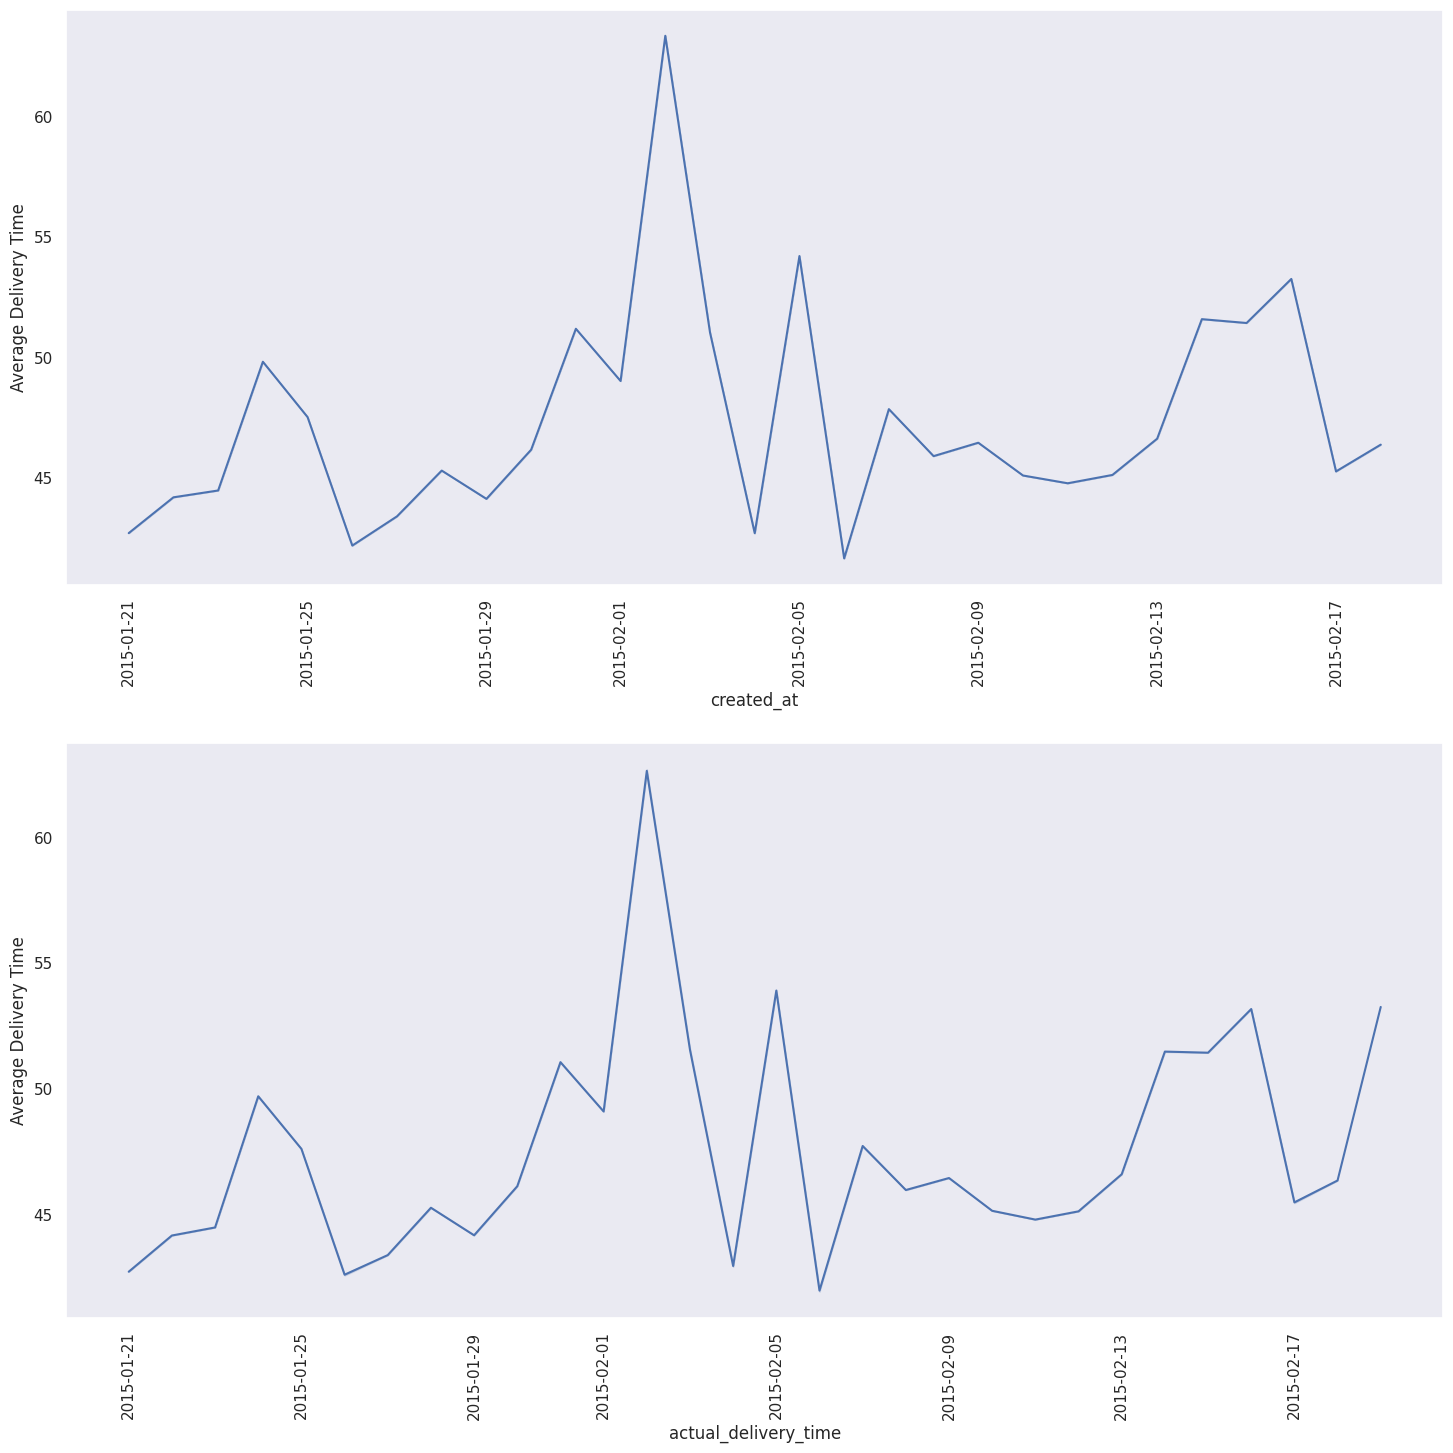

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15,15))
ax = ax.flatten()

for i, col in enumerate(date_cols):
  sns.set(style='dark')
  sns.lineplot(data=data, x=col, y='average_delivery_time', ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_ylabel('Average Delivery Time')
  ax[i].set_xlabel(col)
plt.tight_layout(pad=2)
plt.show()

> ## **Correlation Matrix**:

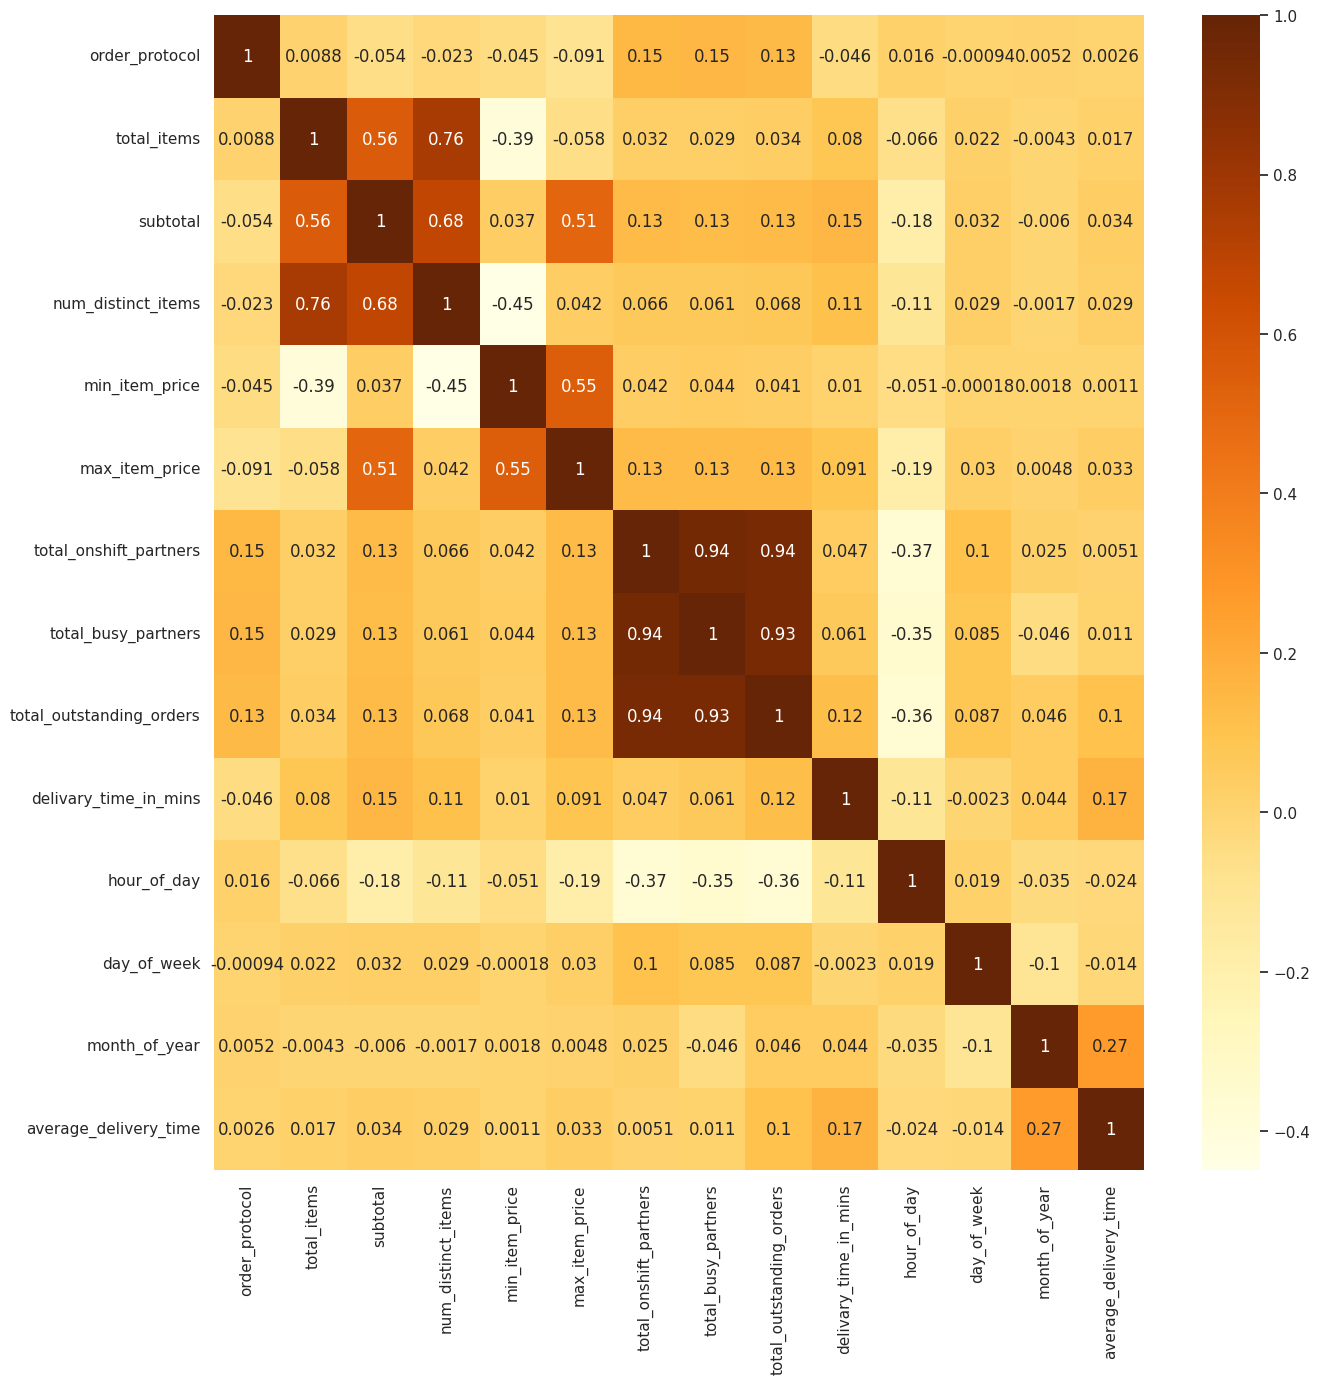

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(numeric_only=True), cmap='YlOrBr', annot=True)
plt.show()

> ### **Insights**:
-  `total_outstanding_order`, `total_busy_partners` and `total_onshift_partners` are very highly correlated with each other.
- `min_item_price` and `max_item_price` are moderately correlated to each other.
- `total_items`, `num_distinct_items` and `subtotal` are highly correlated with each other.
- It seems that target variable `delivery time` is not much correlated with any of the features available, almost 0 relation with all of them.

> ## **Bivariate Analysis**:

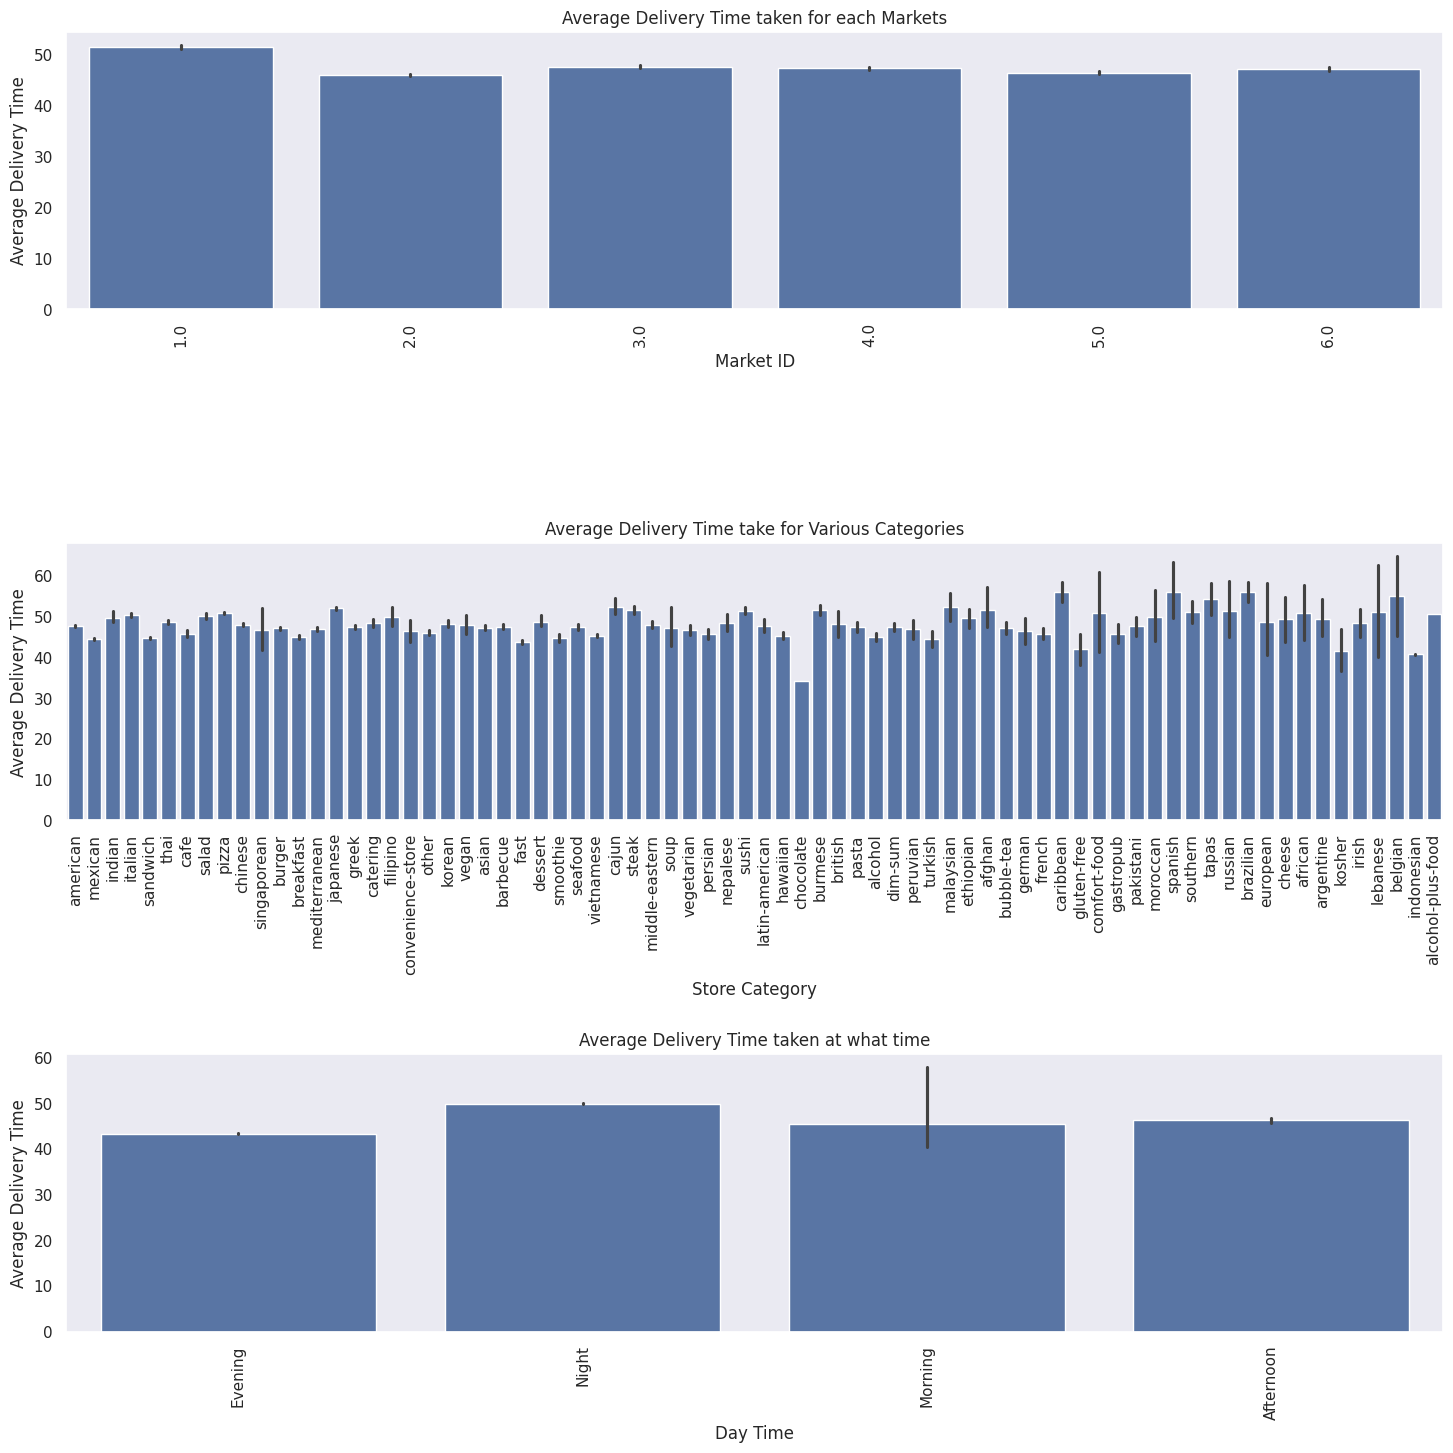

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(15, 15))
ax = ax.flatten()
cat_titles = ['Average Delivery Time taken for each Markets', 'Average Delivery Time take for Various Categories', 'Average Delivery Time taken at what time']
x_labels = ['Market ID', 'Store Category', 'Day Time']

for i, col in enumerate(cat_cols):
  sns.set(style='dark')
  sns.barplot(data=data, x=col, y='delivary_time_in_mins', ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(cat_titles[i])
  ax[i].set_ylabel('Average Delivery Time')
  ax[i].set_xlabel(x_labels[i])
plt.tight_layout(pad=2)
plt.show()

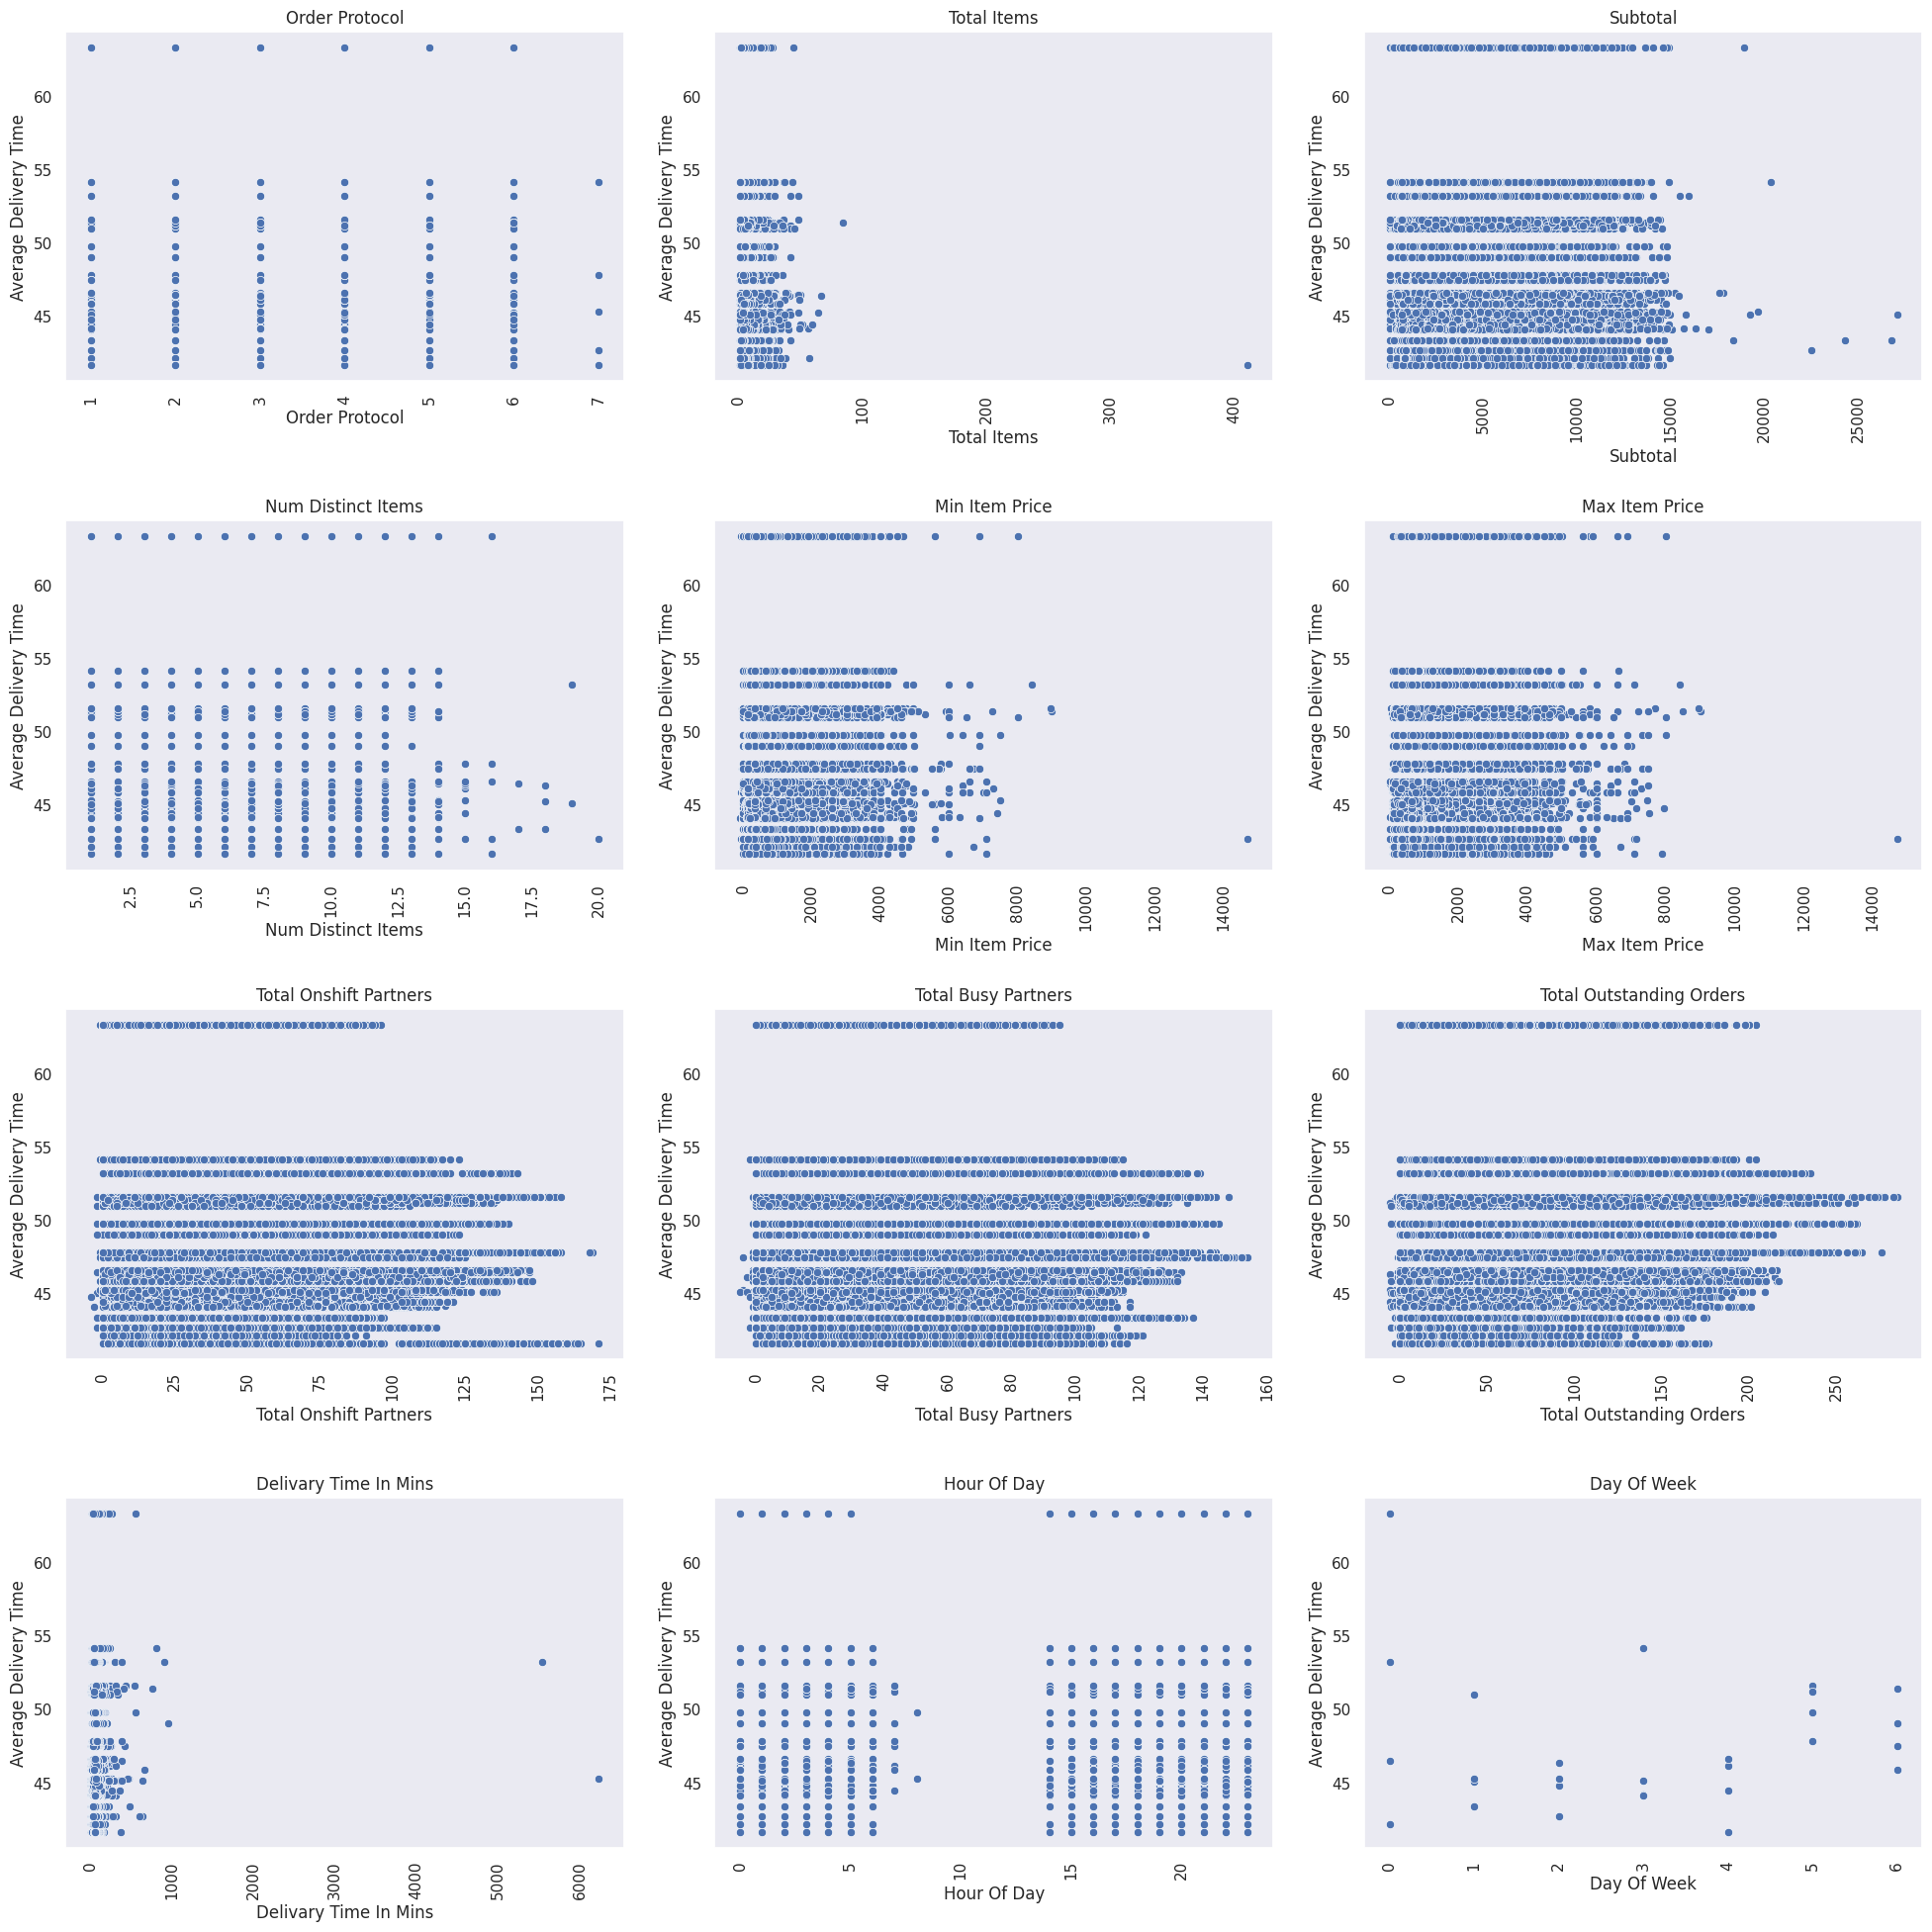

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.set(style='dark')
  sns.scatterplot(data=data, x=col, y='average_delivery_time', ax=ax[i])
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(titles[i])
  ax[i].set_ylabel('Average Delivery Time')
  ax[i].set_xlabel(titles[i])
plt.tight_layout(pad=2)
plt.show()

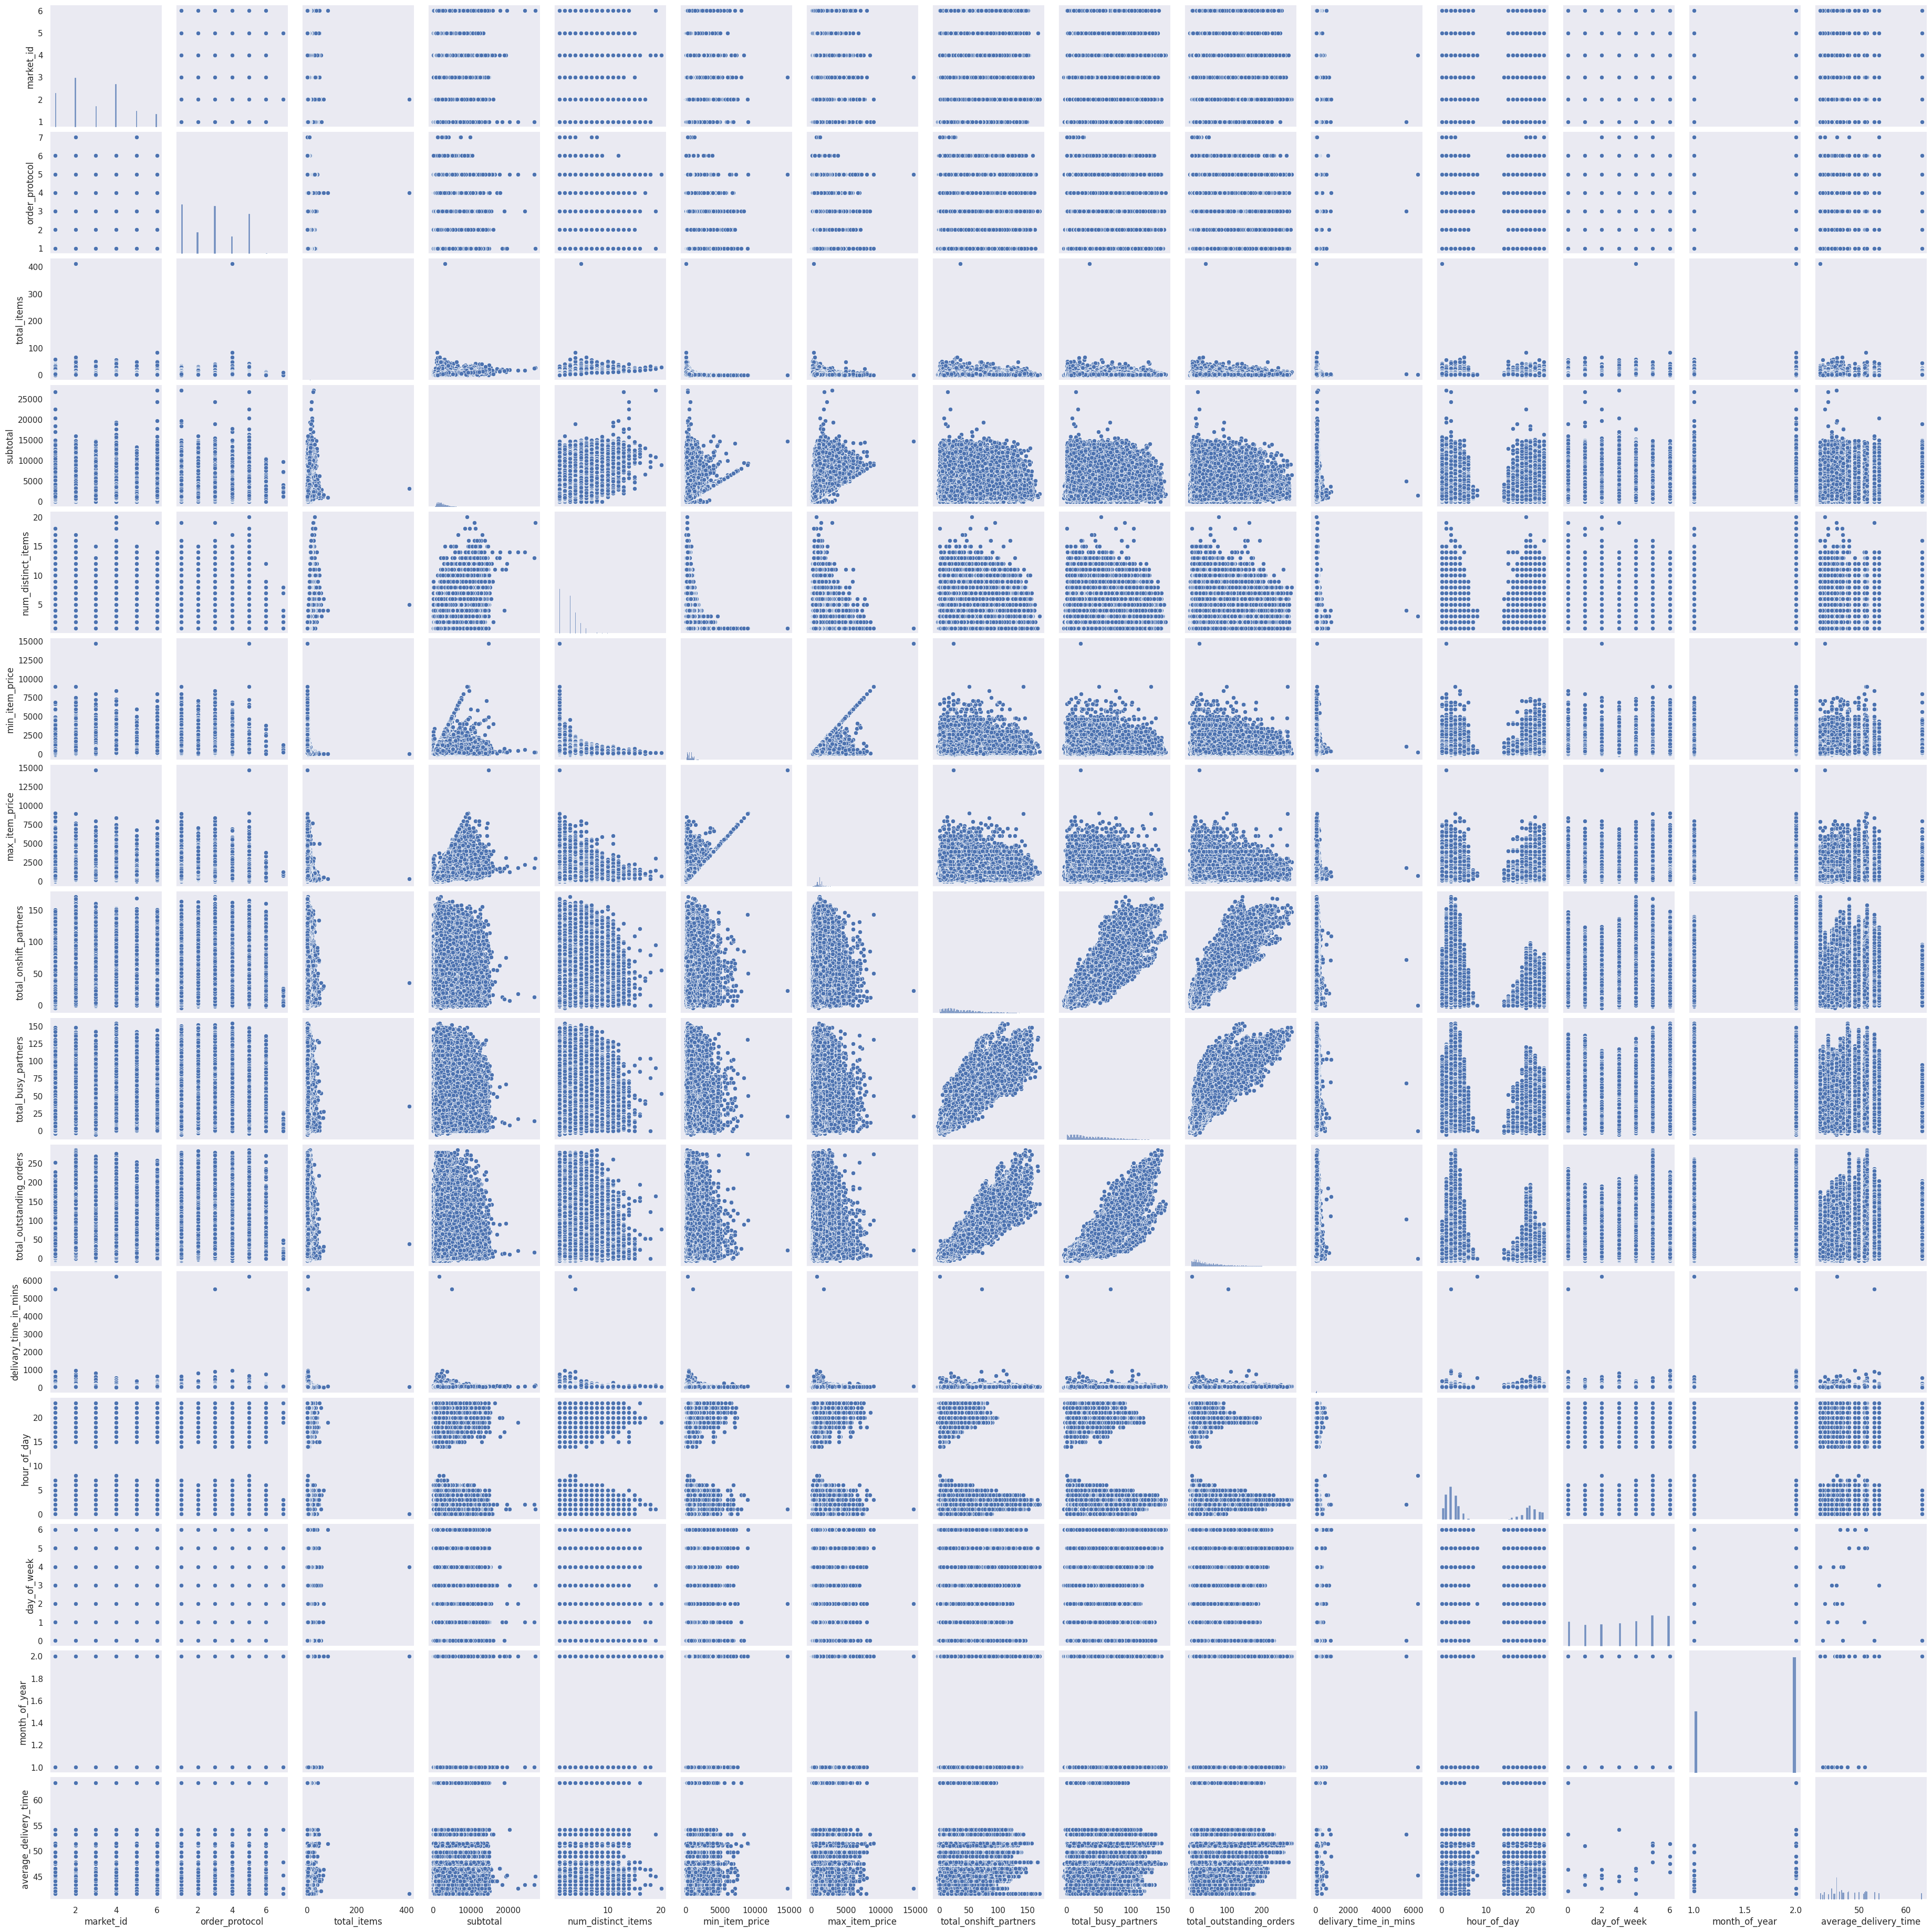

In [ ]:
sns.pairplot(data)
plt.show()

> ## **Multi-variate Analysis**:

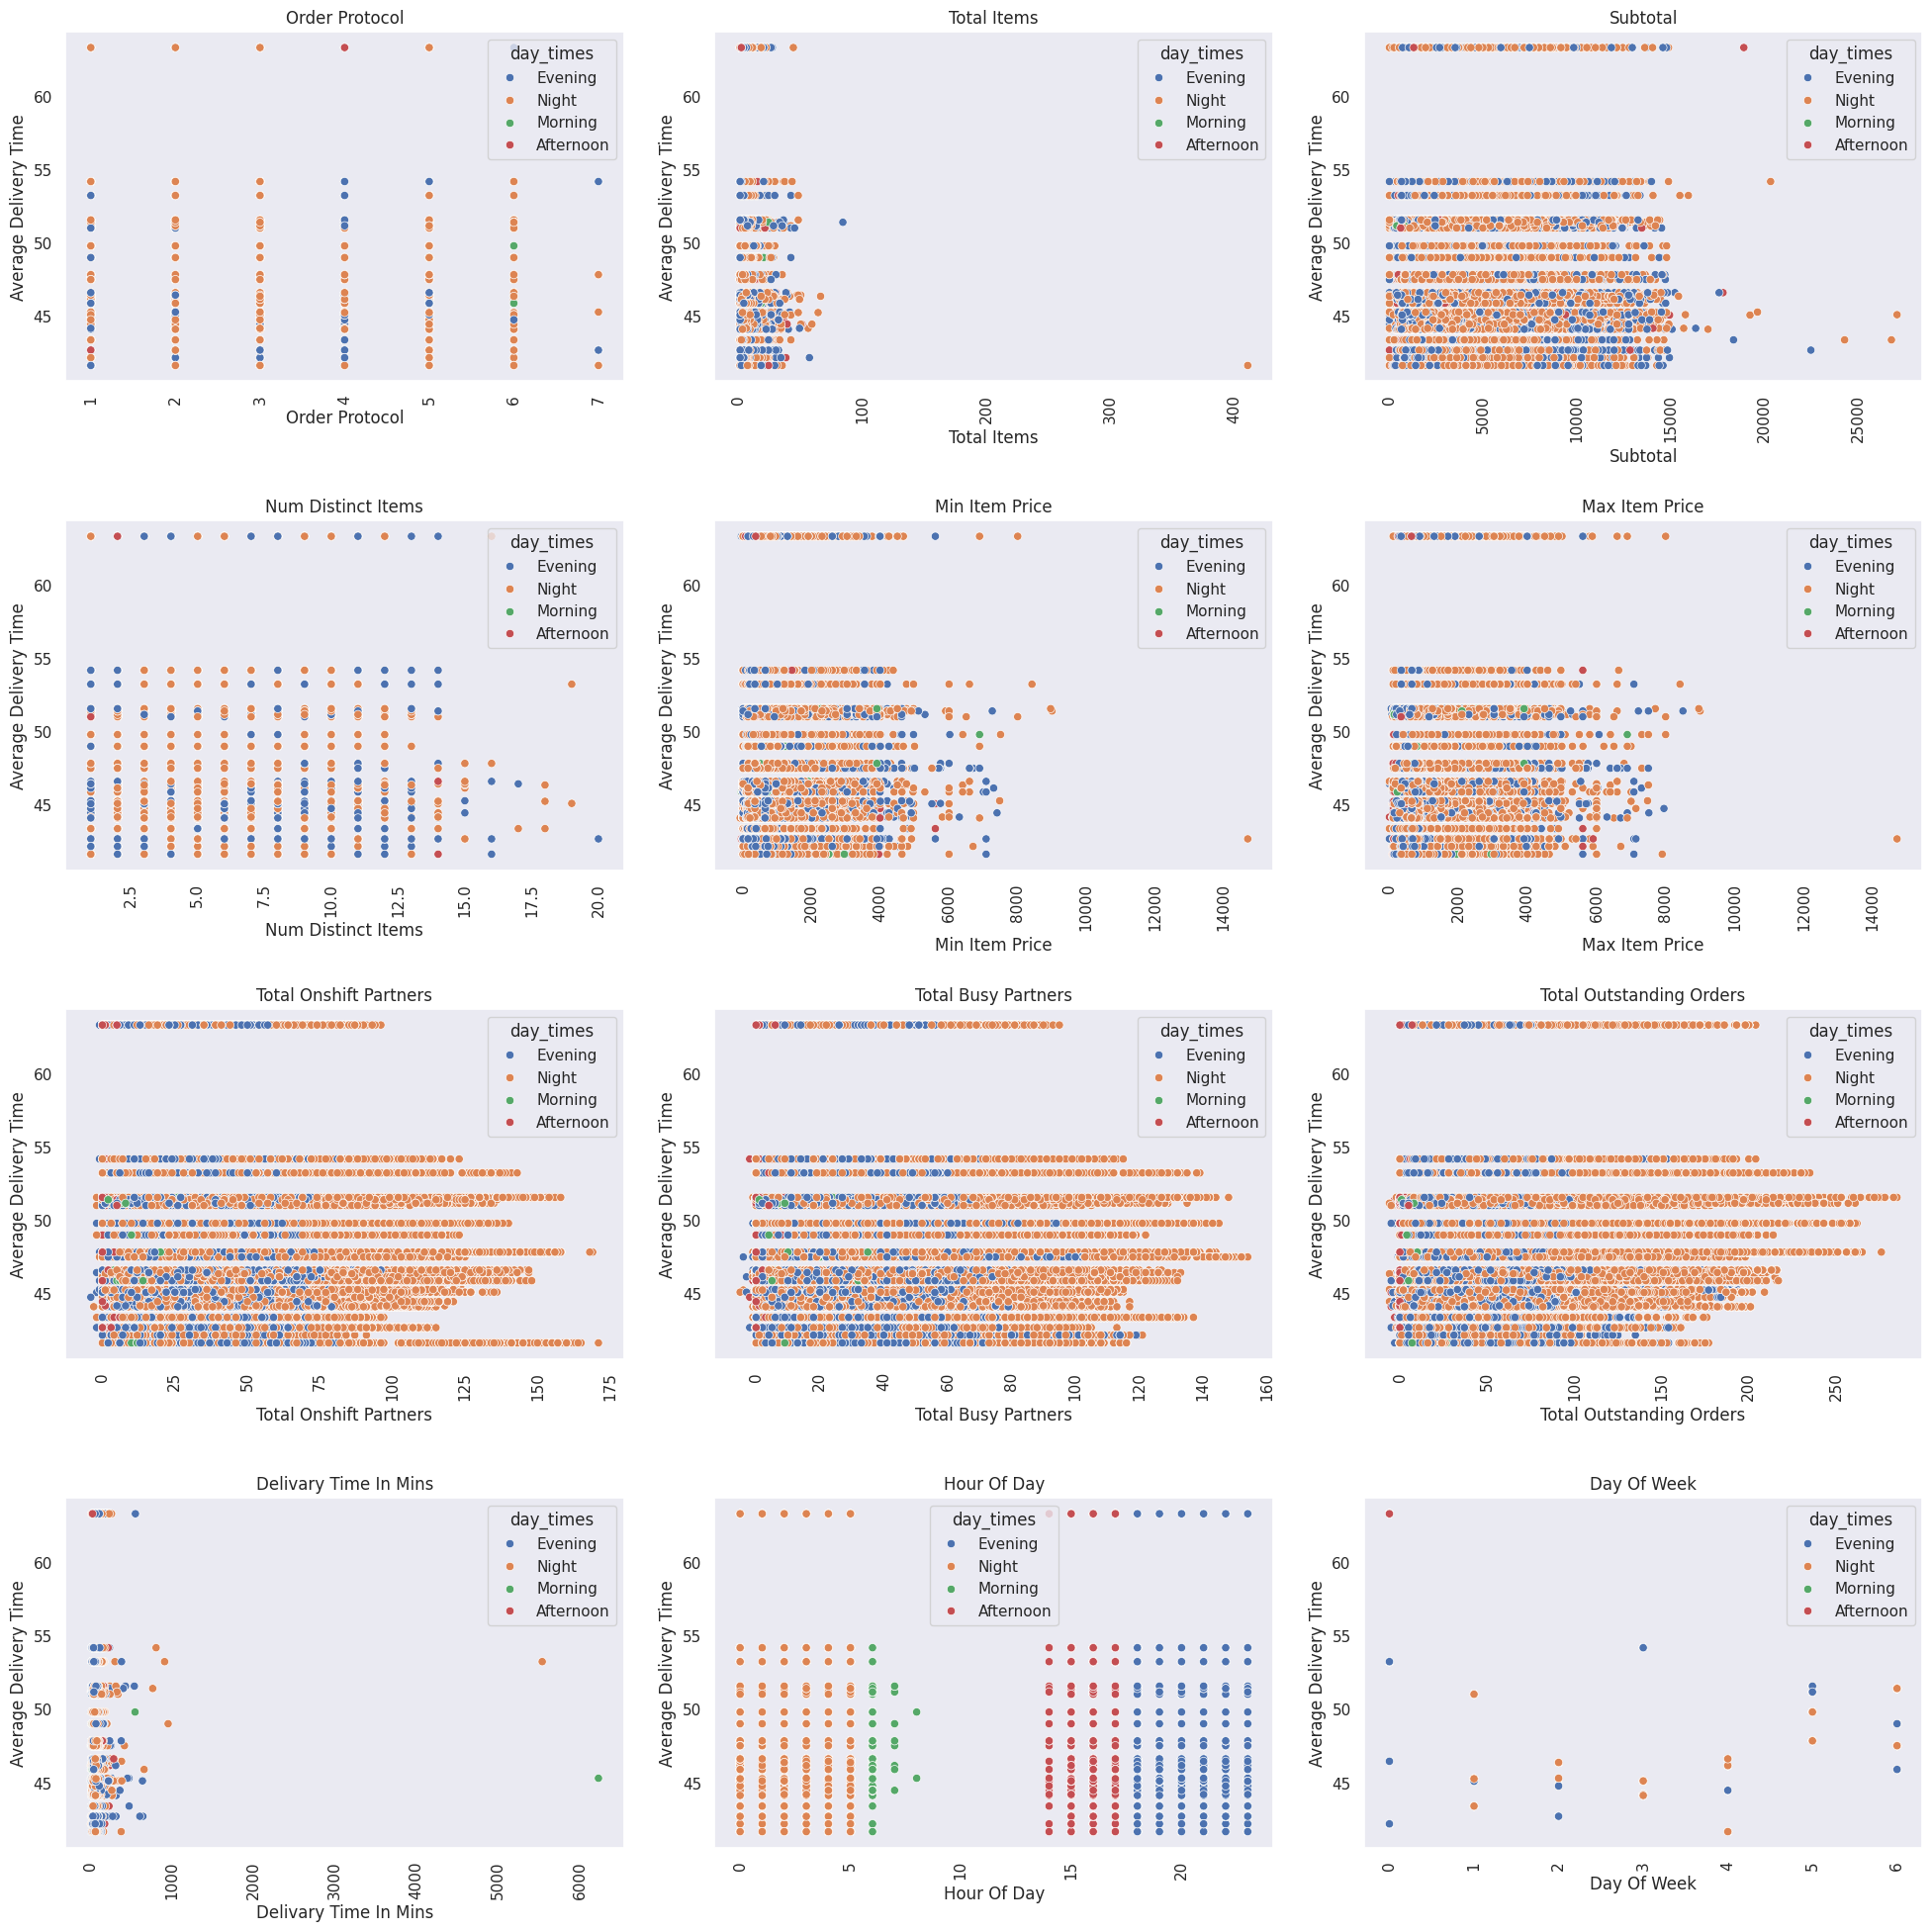

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.set(style='dark')
  sns.scatterplot(data=data, x=col, y='average_delivery_time', ax=ax[i], hue='day_times')
  ax[i].tick_params(axis='x', labelrotation=90)
  ax[i].set_title(titles[i])
  ax[i].set_ylabel('Average Delivery Time')
  ax[i].set_xlabel(titles[i])
plt.tight_layout(pad=2)
plt.show()

> ## **Preprocessing**:

We can drop the columns from which useful details has been already extracted like the dates and day_time as they are now just the redundant features.

In [ ]:
data = data.drop(columns=['created_at', 'actual_delivery_time', 'day_times'])

In [ ]:
data.duplicated().sum()

np.int64(0)

No duplicate record found.

In [ ]:
data['market_id'] = data['market_id'].astype('float64')

In [ ]:
# converting the categorical feature to numeric
data['store_primary_category'] = data['store_primary_category'].astype('category').cat.codes
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197427 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196440 non-null  float64
 1   store_primary_category    197427 non-null  int8   
 2   order_protocol            196432 non-null  float64
 3   total_items               197427 non-null  int64  
 4   subtotal                  197427 non-null  int64  
 5   num_distinct_items        197427 non-null  int64  
 6   min_item_price            197427 non-null  int64  
 7   max_item_price            197427 non-null  int64  
 8   total_onshift_partners    181166 non-null  float64
 9   total_busy_partners       181166 non-null  float64
 10  total_outstanding_orders  181166 non-null  float64
 11  delivary_time_in_mins     197420 non-null  float64
 12  hour_of_day               197427 non-null  int32  
 13  day_of_week               197427 non-null  int32 

> ### **Null Value Imputation**:
- Using **KNNImputer** algorithm to find the best possible values to impute the null values with.
- If algorithm fails to fill some values, we will simply drop them.

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(data[num_cols])
imputed_df = pd.DataFrame(imputed_data, columns=data[num_cols].columns)
imputed_df.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivary_time_in_mins,hour_of_day,day_of_week,month_of_year
0,1.0,4.0,3441.0,4.0,557.0,1239.0,33.0,14.0,21.0,62.983333,22.0,4.0,2.0
1,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,67.066667,21.0,1.0,2.0
2,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,29.683333,20.0,3.0,1.0
3,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,51.250000,21.0,1.0,2.0
4,1.0,3.0,3900.0,3.0,1100.0,1600.0,6.0,6.0,9.0,39.833333,2.0,6.0,2.0


In [ ]:
data[num_cols] = imputed_df
round((data.isnull().sum()/data.shape[0])*100, 2)

,0
market_id,0.5
store_primary_category,0.0
order_protocol,0.0
total_items,0.0
subtotal,0.0
num_distinct_items,0.0
min_item_price,0.0
max_item_price,0.0
total_onshift_partners,0.0
total_busy_partners,0.0


In [ ]:
data['store_primary_category'].fillna('unknown', inplace=True)
print("Before dropping null values", data.shape)
data.dropna(inplace=True)
print("After dropping null values", data.shape)

Before dropping null values (197427, 16)
After dropping null values (196439, 16)


> ### **Outliers Detection and Removal**:
- Using the LocalOutlierFactor (knn implimentation) to detect the possible outliers.
- Once we find them we can simply remove them.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=5)
outliers = lof.fit_predict(data)
outliers = outliers ==-1
data[outliers].shape

(3742, 16)

In [ ]:
print("Before Dropping the outliers: ", data.shape)
data = data[~outliers]
print("After Dropping the outliers: ", data.shape)

Before Dropping the outliers:  (196439, 16)
After Dropping the outliers:  (192697, 16)


In [ ]:
# importing the library to train and evaluate the classical ml models
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
X = data.drop(columns=['delivary_time_in_mins'])
y = data['delivary_time_in_mins']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((154157, 15), (38540, 15), (154157,), (38540,))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

> ## **Random Forest**:

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train_scaled, y_train)
y_pred = rf.predict(x_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MSE: {mse}")
print(f"RMSE: {mse**0.5}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

MAE: 11.204758240536528
MSE: 221.8157132970625
RMSE: 14.893478884970513
R2 Score: 0.27321952028496577
MAPE: 0.2628143331604902


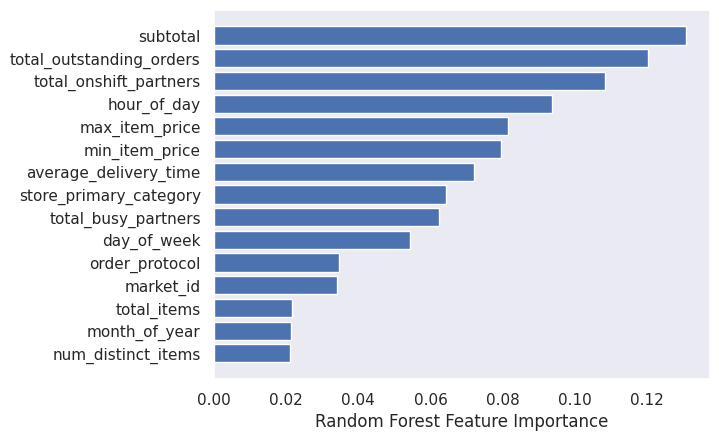

In [ ]:
sorted_ind = rf.feature_importances_.argsort()
plt.barh(X_train.columns[sorted_ind], rf.feature_importances_[sorted_ind])
plt.xlabel("Random Forest Feature Importance")
plt.show()

> ### **Insights**:
- `subtotal` and `total_outstanding_orders` seems to be the most important features as per Random Forest algorithm, meaning basically means that how large an order is and how many orders still in queue will decide how much time delivery will take to arrive.

> ## **Neural Network**:

- We will build a simple neural network to train our regression model
it is a sequential model with three layers.

- We have kept the number of nodes in the first layers equal to the number of input columns, and for the subsequent layers as 512, 1024, 256 which can be changed or experimented with.

- The activation for the layers is kept as relu because it is a great non linear activation function that works for most cases, we could have used leaky relu if we see gradient vanishing.

- The last layer has one node because it will give the single result that is our delivery time and the activation function for that should be linear.

In [ ]:
# importing modules for NN training
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import MeanSquaredLogarithmicError, MeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.metrics import MeanSquaredLogarithmicError, MeanSquaredError, MeanAbsolutePercentageError

In [ ]:
model = Sequential()
model.add(Dense(14, activation='relu', kernel_initializer='normal'))
model.add(Dense(512, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='linear'))

In [ ]:
adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse', 'mae'])
history = model.fit(x_train_scaled, y_train, epochs=30, batch_size=512, verbose=1, validation_split=0.2)

Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 757.0801 - mae: 20.0818 - mse: 757.0801 - val_loss: 244.1828 - val_mae: 11.6384 - val_mse: 244.1828
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - loss: 238.7850 - mae: 11.6275 - mse: 238.7850 - val_loss: 247.1172 - val_mae: 11.3660 - val_mse: 247.1172
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 239.1959 - mae: 11.5865 - mse: 239.1959 - val_loss: 238.4250 - val_mae: 11.7183 - val_mse: 238.4250
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - loss: 236.9120 - mae: 11.5339 - mse: 236.9120 - val_loss: 240.3990 - val_mae: 11.8876 - val_mse: 240.3990
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 239.4388 - mae: 11.5871 - mse: 239.4388 - val_loss: 240.9261 - val_mae: 11.3531 - val_mse: 240.9261
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step - loss: 236.0381 - mae: 11.4988 - mse: 236.0381 - val_loss: 238.5245 - val_mae: 11.3838 - val_mse: 238.5245
Epoch 7/30
241/241 ━━━━━━━━━

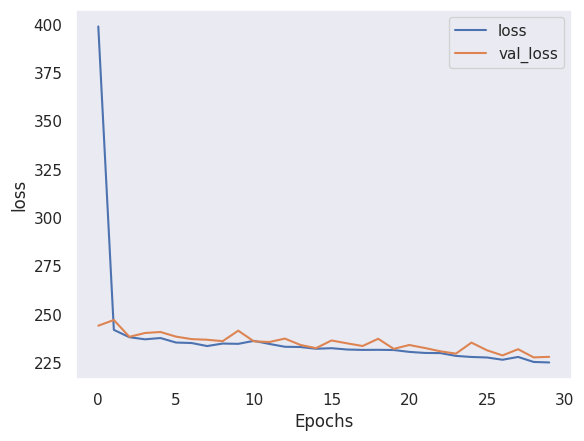

In [ ]:
def plot_history(history, key):
  plt.plot(history.history[key])
  plt.plot(history.history[f'val_{key}'])
  plt.xlabel('Epochs')
  plt.ylabel(key)
  plt.legend([key, f'val_{key}'], loc='upper right')
  plt.show()

plot_history(history, 'loss')

In [ ]:
z = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, z)
print(f"MAE: {mean_absolute_error(y_test, z)}")
print(f"MSE: {mse}")
print(f"RMSE: {mse**0.5}")
print(f"R2 Score: {r2_score(y_test, z)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, z)}")

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
MAE: 11.270030214245356
MSE: 224.38006345720402
RMSE: 14.979321194807328
R2 Score: 0.26481741201300113
MAPE: 0.26414724224904185


- while comparing the R2 scores for both models ie Random Forest and Neural Network we can see NN performing little bit better than RF without any hypertuning.